In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier

In [28]:
# load dataset and keep only features of interest
df = pd.read_csv("agriculture_dataset.csv")

df_f = df[['Elevation_Data','Canopy_Coverage','NDVI', 'SAVI','Chlorophyll_Content', 'Leaf_Area_Index', 'Crop_Stress_Indicator',
       'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Soil_Moisture',
       'Soil_pH', 'Organic_Matter', 'Pest_Hotspots', 'Weed_Coverage',
       'Pest_Damage', 'Crop_Growth_Stage', 'Expected_Yield', 'Crop_Type', 'Water_Flow']].copy()

# keep only wheat data and drop crop type column
df_f2 = df_f[df_f["Crop_Type"] == "Wheat"].copy()
df_f2 = df_f2.drop(columns=["Crop_Type"])

# keep only crop growth stage == 4
df_f2 = df_f2[df_f2["Crop_Growth_Stage"] == 4].copy()

df_label = df[["Crop_Health_Label"]].copy()

In [29]:
df = pd.read_csv("agriculture_dataset.csv")

df_f = df[['Elevation_Data','Canopy_Coverage','NDVI','SAVI','Chlorophyll_Content',
           'Leaf_Area_Index','Crop_Stress_Indicator','Temperature','Humidity',
           'Rainfall','Wind_Speed','Soil_Moisture','Soil_pH','Organic_Matter',
           'Pest_Hotspots','Weed_Coverage','Pest_Damage','Crop_Growth_Stage',
           'Expected_Yield','Crop_Type','Water_Flow','Crop_Health_Label']].copy()

df_f2 = df_f[df_f['Crop_Type'] == 'Wheat'].copy().drop(columns=['Crop_Type'])
df_f2 = df_f2[df_f2['Crop_Growth_Stage'] == 4].copy()

X = df_f2.drop(columns=['Crop_Health_Label', 'Crop_Growth_Stage'])
y = df_f2['Crop_Health_Label']

print(f"Rows: {len(X)}, Features: {X.shape[1]}")
print(f"Target:\n{y.value_counts().to_string()}\n")

# Correlations
print("Correlations with target:")
print(X.corrwith(y).abs().sort_values(ascending=False).to_string(float_format='{:.4f}'.format))

# Baseline
dummy = DummyClassifier(strategy='most_frequent')
print(f"\nDummy F1: {cross_val_score(dummy, X, y, cv=5, scoring='f1_weighted').mean():.4f}")

# Random Forest
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"\n{classification_report(y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

cv = cross_val_score(rf, X, y, cv=5, scoring='f1_weighted')
print(f"\n5-fold CV F1: {cv.mean():.4f} ± {cv.std():.4f}")

Rows: 31927, Features: 19
Target:
Crop_Health_Label
1    22398
0     9529

Correlations with target:
Soil_pH                 0.0106
Soil_Moisture           0.0088
Organic_Matter          0.0082
Temperature             0.0079
Rainfall                0.0043
Elevation_Data          0.0043
Crop_Stress_Indicator   0.0040
Expected_Yield          0.0038
SAVI                    0.0029
Pest_Hotspots           0.0026
Water_Flow              0.0016
Weed_Coverage           0.0015
Canopy_Coverage         0.0014
Chlorophyll_Content     0.0007
Leaf_Area_Index         0.0005
Wind_Speed              0.0005
NDVI                    0.0004
Humidity                0.0003
Pest_Damage             0.0002

Dummy F1: 0.5785


C:\Users\jeanf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jeanf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jeanf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas


              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1906
           1       0.70      1.00      0.82      4480

    accuracy                           0.70      6386
   macro avg       0.35      0.50      0.41      6386
weighted avg       0.49      0.70      0.58      6386

Confusion Matrix:
[[   0 1906]
 [   0 4480]]

5-fold CV F1: 0.5786 ± 0.0002


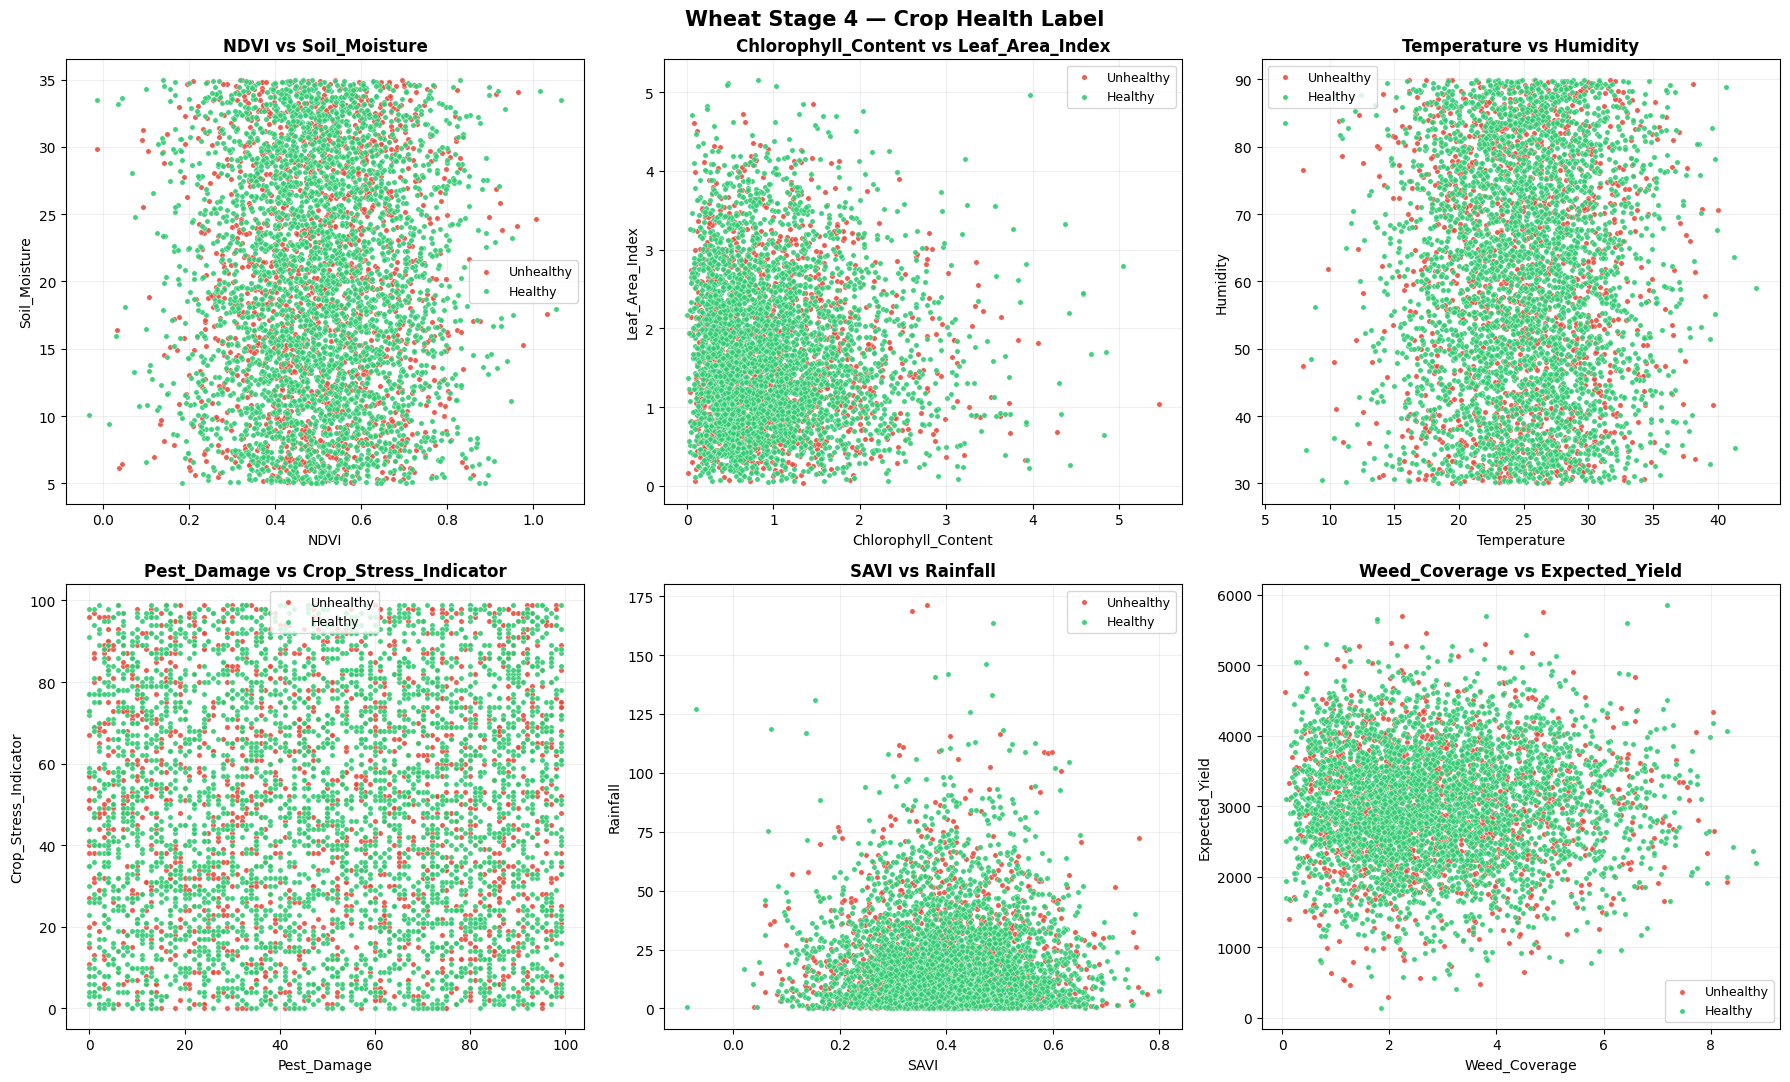

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("agriculture_dataset.csv")
df_w = df[(df['Crop_Type'] == 'Wheat') & (df['Crop_Growth_Stage'] == 4)].copy()

features = ['NDVI','Soil_Moisture','Chlorophyll_Content','Leaf_Area_Index',
            'Temperature','Humidity','Pest_Damage','Crop_Stress_Indicator',
            'SAVI','Rainfall','Weed_Coverage','Expected_Yield']

pairs = [(features[i], features[i+1]) for i in range(0, len(features), 2)]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Wheat Stage 4 — Crop Health Label', fontsize=15, fontweight='bold')

colors = {0: '#e74c3c', 1: '#2ecc71'}
labels = {0: 'Unhealthy', 1: 'Healthy'}

# Sample pour lisibilité
sample = df_w.sample(n=min(5000, len(df_w)), random_state=42)

for ax, (fx, fy) in zip(axes.flat, pairs):
    for c in [0, 1]:
        mask = sample['Crop_Health_Label'] == c
        ax.scatter(sample.loc[mask, fx], sample.loc[mask, fy],
                   c=colors[c], label=labels[c], alpha=0.9, s=15, edgecolors='white', linewidth=0.3)
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.set_title(f'{fx} vs {fy}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('scatter_wheat_stage4.png', dpi=150, bbox_inches='tight')
plt.show()